In [1]:
from the_well.data import WellDataset
from the_well.utils.download import well_download
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Subset
from astropy.io import fits
import pylab as plt
from the_well.benchmark.metrics import VRMSE
from einops import rearrange
import time
import random

## Problem 1

In [2]:
# ── Create Training Data ──────────────────────────────────────────────────────────────
x_train = torch.linspace(-5,5, 200)
y_train = x_train**2 + torch.cos(x_train)
#Possible even functions tested
#   torch.cos(x_train) 
#   x_train ** 2 
#   x_train ** 4 +  x_train ** 2 + 1

In [3]:
# ── Symmetrized Architecture ──────────────────────────────────────────────────────────────
class Symmetrized(nn.Module):
    """
    Multi-layer perceptron with configurable architecture.
    """
    
    def __init__(self, 
                 layer_size: int, 
                 activation: nn.Module):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1,layer_size),
            activation(),
            nn.Linear(layer_size,1)
        )
       
    def forward(self, x):
        return self.net(x.abs()) #The symmetry constraint
    

In [4]:
# ── Non-symmetrized architecture ──────────────────────────────────────────────────────────────
class NotSymmetrized(nn.Module):
    """
    Multi-layer perceptron with configurable architecture.
    """
    
    def __init__(self, 
                 layer_size: int, 
                 activation: nn.Module):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1,layer_size),
            activation(),
            nn.Linear(layer_size,1)
        )
       
    def forward(self, x):
        return self.net(x)
    

In [5]:
# ── Train Symmetrized model show evaluated versus actual ──────────────────────────────────────────────────────────────
LEARNING_RATE = 1e-3
LAYER_SIZE = 128
EPOCHS = 1000

model = Symmetrized(
        layer_size= LAYER_SIZE, 
        activation= nn.ReLU
    )


loss_fn = nn.MSELoss() #Try MSELoss, L1Loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

model.train()

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    y_pred = model(x_train.unsqueeze(-1))  # shape (200, 1)
    loss = loss_fn(y_pred.squeeze(), y_train)
    loss.backward()
    optimizer.step()

y_calculated = model(x_train.unsqueeze(-1))

ySymmetrized = (y_calculated.detach()).squeeze() ##Change based on which data is being collected

plt.plot(x_train, y_train, "r", label="Actual")
plt.plot(x_train, y_calculated.detach(), "b", label="Calculated")
plt.legend()
plt.show()


/var/folders/vr/krfxbdzj66xclmv38bj33szc0000gn/T/ipykernel_25608/2343349609.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
# ── Train Non-Symmetrized model show evaluated versus actual ──────────────────────────────────────────────────────────────
model = NotSymmetrized(
        layer_size= LAYER_SIZE, 
        activation= nn.ReLU
    )


loss_fn = nn.MSELoss() #Try MSELoss, L1Loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

model.train()

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    y_pred = model(x_train.unsqueeze(-1))  # shape (200, 1)
    loss = loss_fn(y_pred.squeeze(), y_train)
    loss.backward()
    optimizer.step()

y_calculated = model(x_train.unsqueeze(-1))

yNotSymmetrized = (y_calculated.detach()).squeeze() ##Change based on which data is being collected

plt.plot(x_train, y_train, "r", label="Actual")
plt.plot(x_train, y_calculated.detach(), "b", label="Calculated")
plt.legend()


In [7]:
# ── Visualize errors (Plot residuals) ──────────────────────────────────────────────────────────────
symmetrizedResiduals = ySymmetrized - y_train
notSymmetrizedResiduals = yNotSymmetrized - y_train
l1_lossSym = torch.abs(ySymmetrized - y_train).mean()
l1_lossNotSym = torch.abs(yNotSymmetrized - y_train).mean()

print("L1 loss using symmetrized architecture: ", l1_lossSym)
print("L1 loss using Nonsymmetrized architecture: ", l1_lossNotSym)
plt.plot(x_train, symmetrizedResiduals, "red", label="Symmetrized")
plt.plot(x_train, notSymmetrizedResiduals, "blue",  label="Not Symmetrized")
plt.legend()
plt.xlabel("training data point")
plt.ylabel("Raw Residuals")
plt.title("Cos function performance")



L1 loss using symmetrized architecture:  tensor(0.2796)
L1 loss using Nonsymmetrized architecture:  tensor(1.1029)


Text(0.5, 1.0, 'Cos function performance')

## Problem 2

Start running the code from here. 

In [8]:
# ── Download Data ──────────────────────────────────────────────────────────────
BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'
SPLIT = 'valid'

well_download(base_path=BASE_PATH, dataset=DATASET, split=SPLIT)


** Resuming transfer from byte position 576
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0    175      0  0:00:01  0:00:01 --:--:--   177
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   197  100   197    0     0    422      0 --:--:-- --:--:-- --:--:--   430
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   2020      0 --:--:-- --:--:-- --:--:--  2030
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   1863      0 --:--:-- --:--:-- --:--:--  1876
** Resuming transfer from byte position 79459648
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   197  100   197    0     0   1354      0 --:--:-- --:--:-- --:--:--  1349
** Resuming transfer from byte position 79459648
  % Total    %

In [9]:
# ── Create/Save data ──────────────────────────────────────────────────────────────
train_dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name='train',
    use_normalization=True #This is the only "preprocessing" I am doing
)

val_dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name='valid',
    use_normalization=True
)

test_dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name='test',
    use_normalization=True
)

idx = 107
channel_id = 0 #These are each of the 4 fields we can measure 
plt.imshow(train_dataset[idx]['input_fields'][0][:,:,channel_id])

#Model needs to take in input_fields and predict output_fields

In [10]:
# ── Symmetrized part of architecture ──────────────────────────────────────────────────────────────
class PeriodicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.pad_x = kernel_size // 2
        self.pad_y = kernel_size // 2
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=0)

    def forward(self, x):
        x = F.pad(x, (self.pad_x, self.pad_x, 0, 0), mode='circular')  # IMPORTANT SYMMETRY ENFORCING x: circular -> translational invariance
        x = F.pad(x, (0, 0, self.pad_y, self.pad_y), mode='constant', value=0)  # IMPORTANT SYMMETRY ENFORCING y: zero -> zero gradient boundary condition
        return self.conv(x) #Performs the actual convolution


In [11]:
# ── Convolution Block ──────────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            PeriodicConv2d(in_channels, out_channels),
            nn.GroupNorm(4, out_channels), #Divides channels into 4 groups and normalizes within each group to fix stability
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)



In [12]:
# ──  Final Architecture ──────────────────────────────────────────────────────────────
class EquivariantEncoderDecoder(nn.Module):
    def __init__(self, in_channels=4, base_channels=16): 
        super().__init__()

        self.enc1      = ConvBlock(in_channels, base_channels) #Expands into 16 channels
        self.pool      = nn.MaxPool2d(2) #Takes the max value in a 2x2 window -> Coarsens
        self.bottleneck = ConvBlock(base_channels, base_channels*2) #Expands into 32 channels this time
        self.up1       = nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=2, stride=2) #Reconstructs the image
        self.dec1      = ConvBlock(base_channels, base_channels) # Refines the reconstructed image and incorporates the symmetries again.
        self.out_conv  = nn.Conv2d(base_channels, in_channels, kernel_size=1) #Simple convolution back to the 4 channels we began with

    def forward(self, x):
        e1  = self.enc1(x)
        b   = self.bottleneck(self.pool(e1))
        d1  = self.dec1(self.up1(b))
        out = self.out_conv(d1)
        return out

In [13]:
# ── Baseline Architecture ──────────────────────────────────────────────────────────────
class BaselineEncoderDecoder(nn.Module):
    def __init__(self, in_channels=4, base_channels=16):
        super().__init__()

        self.enc1       = self.conv_block(in_channels, base_channels)
        self.pool       = nn.MaxPool2d(2)
        self.bottleneck = self.conv_block(base_channels, base_channels*2) 
        self.up1        = nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=2, stride=2)
        self.dec1       = self.conv_block(base_channels, base_channels)
        self.out_conv   = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels): #This is the only change
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, padding_mode='zeros'),  #This is changed padding to no longer be circular
            nn.GroupNorm(4, out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        e1  = self.enc1(x)
        b   = self.bottleneck(self.pool(e1))
        d1  = self.dec1(self.up1(b))
        out = self.out_conv(d1)
        return out

In [ ]:
# ── DEFINE HYPERPARAMETERS ────────────────────────────────────────────────────────────────────
BATCH_SIZE   = 10
EPOCHS       = 10
LEARNING_RATE = 1e-4
DEVICE       = torch.device('cpu') #'cuda' is not available

# ── DataLoader ──────────────────────────────────────────────────────────────────────
train_loader = DataLoader(Subset(train_dataset, range(100)), batch_size=BATCH_SIZE, shuffle=True)            #Subset(train_dataset, range(10)) when testing, and use train_dataset when not

# ── Training loop ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for batch in loader:
        # input_fields: (batch, time, H, W, channels) → we want (batch, channels, H, W)
        x = batch['input_fields'].to(DEVICE).float()   # (B, Ti, H, W, F)
        y = batch['output_fields'].to(DEVICE).float()  # (B, To, H, W, F)

        x_in = rearrange(x, "B Ti Lx Ly F -> B (Ti F) Lx Ly")
        y_in = rearrange(y, "B To Lx Ly F -> B (To F) Lx Ly")

        optimizer.zero_grad()
        pred = model(x_in)
        loss = loss_fn(pred, y_in)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# ── Validation loop ───────────────────────────────────────────────────────────
def evaluate(model, dataset):
    model.eval()
    metric = VRMSE()
    total_vrmse = 0

    with torch.no_grad():
        for i in range(len(dataset)):
            item = dataset[i]

            x = item['input_fields'].to(DEVICE).float()   # (Ti, H, W, F)
            y = item['output_fields'].to(DEVICE).float()  # (To, H, W, F)

            x_in = rearrange(x, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

            pred = model(x_in)
            pred = rearrange(pred, "1 (To F) Lx Ly -> To Lx Ly F", F=4)

            # call it like a function — uses forward() internally
            score = metric(pred, y, dataset.metadata)  # add metadata here
            total_vrmse += score.mean().item()

    return total_vrmse / len(dataset)

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [ ]:
# ── Train equivariant model ──────────────────────────────────────────────────────────────
model     = EquivariantEncoderDecoder(in_channels=4, base_channels=16).to(DEVICE)
# ── optimizer, loss ────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn   = nn.MSELoss()

best_val_vrmse = float('inf')
train_start = time.time()
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    val_vrmse  = evaluate(model, val_dataset)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | train MSE: {train_loss:.4f} | val VRMSE: {val_vrmse:.4f}")
    # Save best model
    if val_vrmse < best_val_vrmse:
        epochs_without_improvement = 0
        best_val_vrmse = val_vrmse
        torch.save(model.state_dict(), 'best_model_equivariant.pt')

    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= 3:
            print(f"Early stopping at epoch {epoch+1}")
            break

total_time = time.time() - train_start
print(f"\nBest val VRMSE: {best_val_vrmse:.4f}")
print("Total time to train: ", total_time, " seconds")

Epoch   1/10 | train MSE: 770.5337 | val VRMSE: 40.2081
Epoch   2/10 | train MSE: 766.0315 | val VRMSE: 39.5233
Epoch   3/10 | train MSE: 763.5929 | val VRMSE: 38.5939
Epoch   4/10 | train MSE: 761.9249 | val VRMSE: 37.3382
Epoch   5/10 | train MSE: 760.5762 | val VRMSE: 36.3824
Epoch   6/10 | train MSE: 759.3683 | val VRMSE: 36.0139
Epoch   7/10 | train MSE: 758.3178 | val VRMSE: 36.0147
Epoch   8/10 | train MSE: 757.4367 | val VRMSE: 35.9658
Epoch   9/10 | train MSE: 756.6580 | val VRMSE: 35.6770
Epoch  10/10 | train MSE: 755.9185 | val VRMSE: 35.1507

Best val VRMSE: 35.1507
Total time to train:  298.2164030075073  seconds


Shape check passed ✓ — output shape: torch.Size([1, 4, 128, 384])
Equivariance error: 0.000001
Equivariance check passed ✓


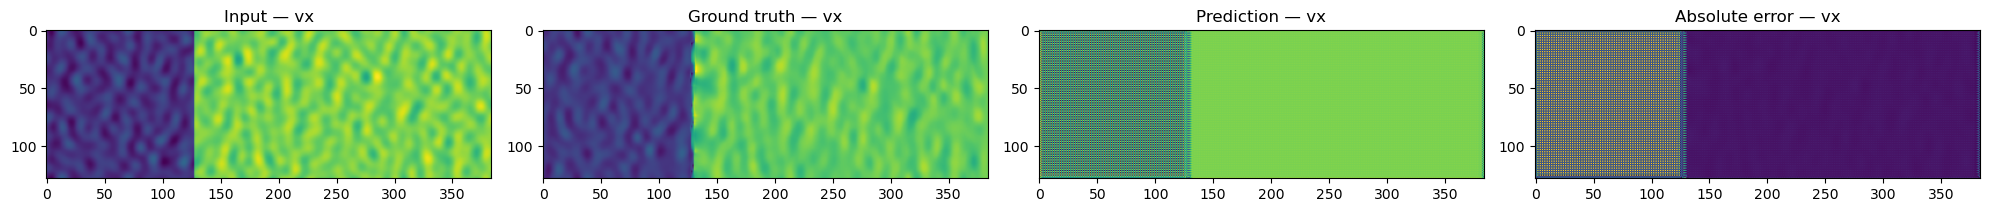

In [37]:
# ── Equivariant model Sanity Checks ──────────────────────────────────────────────────────────────
model.eval()

model = EquivariantEncoderDecoder(in_channels=4, base_channels=16).to(DEVICE)
x = torch.randn(1, 4, 128, 384).to(DEVICE)
out = model(x)
assert out.shape == x.shape, f"Shape mismatch: {out.shape} vs {x.shape}"
print(f"Shape check passed ✓ — output shape: {out.shape}")

x = torch.randn(1, 4, 128, 384).to(DEVICE)

# shift by 50 pixels in x
shift = 50
x_shifted = torch.roll(x, shifts=shift, dims=3)

with torch.no_grad():
    out = model(x)
    out_shifted = model(x_shifted)

# output of shifted input should equal shifted output
error = (torch.roll(out, shifts=shift, dims=3) - out_shifted).abs().max()
print(f"Equivariance error: {error.item():.6f}")  # should be near 0
assert error < 1e-4, "Equivariance check failed!"
print("Equivariance check passed ✓")


# ── To see one specific test case  ──────────────────────────────────────────────────────────────
idx = 100

channel_id = 2  # 0=density, 1=pressure, 2=vx, 3=vy
channel_names = ['Density', 'Pressure', 'vx', 'vy']

item = val_dataset[idx]
x = item['input_fields'].to(DEVICE).float()
y = item['output_fields'].to(DEVICE).float()

x_in = rearrange(x, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

with torch.no_grad():
    pred = model(x_in)
    pred = rearrange(pred, "1 (To F) Lx Ly -> To Lx Ly F", F=4)

# plot input, prediction, ground truth, and error side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].imshow(x[0, :, :, channel_id].cpu())
axes[0].set_title(f'Input — {channel_names[channel_id]}')

axes[1].imshow(y[0, :, :, channel_id].cpu())
axes[1].set_title(f'Ground truth — {channel_names[channel_id]}')

axes[2].imshow(pred[0, :, :, channel_id].cpu())
axes[2].set_title(f'Prediction — {channel_names[channel_id]}')

error = (pred[0, :, :, channel_id] - y[0, :, :, channel_id]).abs().cpu()
axes[3].imshow(error)
axes[3].set_title(f'Absolute error — {channel_names[channel_id]}')

plt.tight_layout()
plt.show()

In [21]:

# ── Train Baseline model ──────────────────────────────────────────────────────────────
# del baseline
baseline     = BaselineEncoderDecoder(in_channels=4, base_channels=16).to(DEVICE)

# ── optimizer, loss ────────────────────────────────────────────────────
baseline_optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)
baseline_loss_fn = nn.MSELoss()

best_val_vrmse = float('inf')
train_start = time.time()

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(baseline, train_loader, baseline_optimizer, baseline_loss_fn)
    val_vrmse  = evaluate(baseline, val_dataset)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | train MSE: {train_loss:.4f} | val VRMSE: {val_vrmse:.4f}")
    
    # Save best model
    if val_vrmse < best_val_vrmse:
        epochs_without_improvement = 0
        best_val_vrmse = val_vrmse
        torch.save(baseline.state_dict(), 'best_model_baseline.pt')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= 3:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
total_time = time.time() - train_start
print(f"\nBest val VRMSE: {best_val_vrmse:.4f}")
print("Total time to train: ", total_time)

Epoch   1/10 | train MSE: 782.3662 | val VRMSE: 32.5659
Epoch   2/10 | train MSE: 774.0132 | val VRMSE: 33.7756
Epoch   3/10 | train MSE: 766.6468 | val VRMSE: 33.5090
Epoch   4/10 | train MSE: 760.8327 | val VRMSE: 32.4603
Epoch   5/10 | train MSE: 756.2625 | val VRMSE: 31.6099
Epoch   6/10 | train MSE: 752.6185 | val VRMSE: 31.1331
Epoch   7/10 | train MSE: 749.9024 | val VRMSE: 31.6212
Early stopping at epoch 7

Best val VRMSE: 31.1331
Total time to train:  193.69344997406006


In [ ]:
# %matplotlib inline

Shape check passed ✓ — output shape: torch.Size([1, 4, 128, 384])
Baseline equivariance error: 1.877257
Baseline correctly breaks equivariance ✓


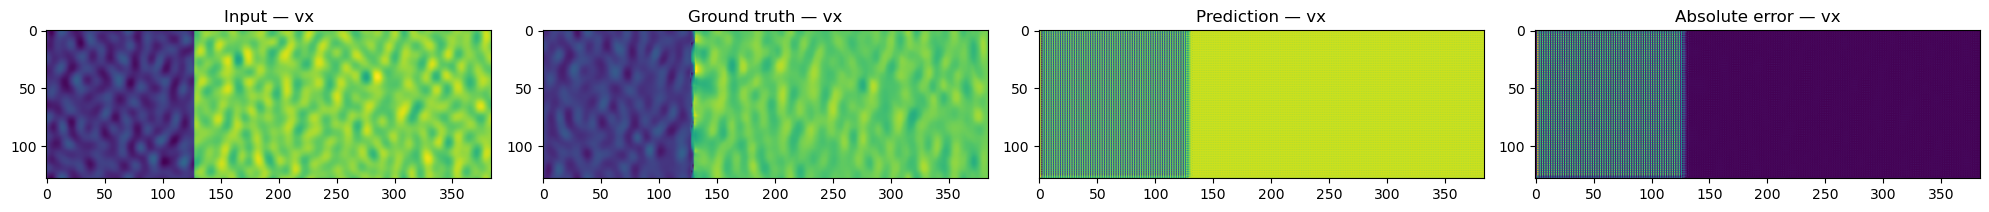

In [38]:
# ── Baseline Sanity Checks ──────────────────────────────────────────────────────────────
baseline.eval()


x = torch.randn(1, 4, 128, 384).to(DEVICE)
out = baseline(x)
assert out.shape == x.shape, f"Shape mismatch: {out.shape} vs {x.shape}"
print(f"Shape check passed ✓ — output shape: {out.shape}")

with torch.no_grad():
    out = baseline(x)
    out_shifted = baseline(x_shifted)

error_baseline = (torch.roll(out, shifts=shift, dims=3) - out_shifted).abs().max()
print(f"Baseline equivariance error: {error_baseline.item():.6f}")  # should be large
print("Baseline correctly breaks equivariance ✓" if error_baseline > 1e-4 else "Warning: baseline is accidentally equivariant")

# ── To see one specific test case  ──────────────────────────────────────────────────────────────
idx = 100

channel_id = 2  # 0=density, 1=pressure, 2=vx, 3=vy
channel_names = ['Density', 'Pressure', 'vx', 'vy']

item = val_dataset[idx]
x = item['input_fields'].to(DEVICE).float()
y = item['output_fields'].to(DEVICE).float()

x_in = rearrange(x, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

with torch.no_grad():
    pred = baseline(x_in)
    pred = rearrange(pred, "1 (To F) Lx Ly -> To Lx Ly F", F=4)

# plot input, prediction, ground truth, and error side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].imshow(x[0, :, :, channel_id].cpu())
axes[0].set_title(f'Input — {channel_names[channel_id]}')

axes[1].imshow(y[0, :, :, channel_id].cpu())
axes[1].set_title(f'Ground truth — {channel_names[channel_id]}')

axes[2].imshow(pred[0, :, :, channel_id].cpu())
axes[2].set_title(f'Prediction — {channel_names[channel_id]}')

error = (pred[0, :, :, channel_id] - y[0, :, :, channel_id]).abs().cpu()
axes[3].imshow(error)
axes[3].set_title(f'Absolute error — {channel_names[channel_id]}')

plt.tight_layout()
plt.show()

In [26]:
# ── Check Robustness to Seeds ────────────────────────────────────────
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def train_and_evaluate(model_class, seed, epochs=EPOCHS):
    set_seed(seed)
    
    m         = model_class(in_channels=4, base_channels=16).to(DEVICE)
    opt       = optim.Adam(m.parameters(), lr=LEARNING_RATE)
    lfn       = nn.MSELoss()

    # training
    for epoch in range(3):
        train_loss = train_one_epoch(m, train_loader, opt, lfn) 
    
    # evaluation
    eval_start = time.time()
    val_vrmse  = evaluate(m, val_dataset)
    eval_time  = time.time() - eval_start
    
    return {
        'val_vrmse':   val_vrmse,
        'eval_time':   eval_time,
        'train_loss':  train_loss,
    }

SEEDS = [17, 34, 36]

equivariant_results = []
baseline_results    = []

for seed in SEEDS:
    print(f"\nSeed {seed}")
    
    print("  Training equivariant model...")
    eq_result = train_and_evaluate(EquivariantEncoderDecoder, seed)
    equivariant_results.append(eq_result)
    print(f"  val VRMSE: {eq_result['val_vrmse']:.4f}")
    
    print("  Training baseline model...")
    bl_result = train_and_evaluate(BaselineEncoderDecoder, seed)
    baseline_results.append(bl_result)
    print(f"  val VRMSE: {bl_result['val_vrmse']:.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
def summarize(results, name):
    vrmse_scores = [r['val_vrmse']  for r in results]
    print(f"\n{name}")
    print(f"  val VRMSE: {np.mean(vrmse_scores):.4f} ± {np.std(vrmse_scores):.4f}")

summarize(equivariant_results, "Equivariant model")
summarize(baseline_results,    "Baseline model")



Seed 17
  Training equivariant model...
  val VRMSE: 43.5224
  Training baseline model...
  val VRMSE: 43.6331

Seed 34
  Training equivariant model...
  val VRMSE: 48.1567
  Training baseline model...
  val VRMSE: 48.2964

Seed 36
  Training equivariant model...
  val VRMSE: 43.3022
  Training baseline model...
  val VRMSE: 43.3046

Equivariant model
  val VRMSE: 44.9937 ± 2.2383

Baseline model
  val VRMSE: 45.0780 ± 2.2796


In [28]:
# ── Test Final Architecture  ──────────────────────────────────────────────────────────────

train_start = time.time()
model.load_state_dict(torch.load('best_model_equivariant.pt'))
test_vrmse = evaluate(model, test_dataset)
print(f"Test VRMSE: {test_vrmse:.4f}")

total_time = time.time() - train_start
print("Total time to test equivariant architecture: ", total_time)



train_start = time.time()
baseline.load_state_dict(torch.load('best_model_baseline.pt'))
test_vrmse = evaluate(baseline, test_dataset)
print(f"Test VRMSE: {test_vrmse:.4f}")


total_time = time.time() - train_start
print("Total time to test baseline architecture: ", total_time)


/var/folders/vr/krfxbdzj66xclmv38bj33szc0000gn/T/ipykernel_25608/2853749826.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_

Test VRMSE: 32.1689
Total time to test equivariant architecture:  31.358132123947144


/var/folders/vr/krfxbdzj66xclmv38bj33szc0000gn/T/ipykernel_25608/2853749826.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline.load_state_dict(torch.load('best_mo

Test VRMSE: 29.0591
Total time to test baseline architecture:  27.25617790222168
